# Least Squares Code Challenges and Solutions to Practice Questions

## Random attempt at trying to implement some model fitting

[  6   5   1 -10   3  -2   1  -6] [[1. 0.]
 [1. 1.]
 [1. 2.]
 [1. 3.]
 [1. 4.]
 [1. 5.]
 [1. 6.]
 [1. 7.]]
[ 3.91666667 -1.19047619]


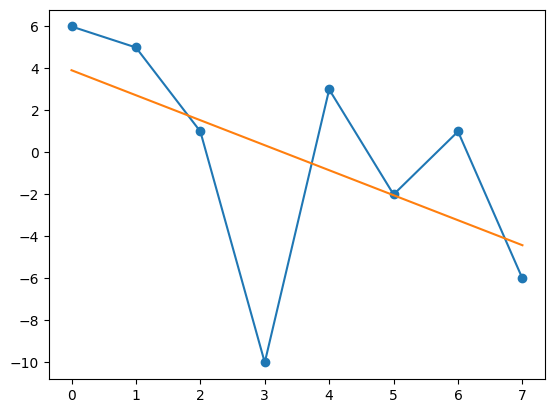

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate some random data (this is the y we are trying to fit a model to)
y = np.random.randint(-10, 10, 8)

# Column 1 of the design matrix (X), which is the intercept (the mean)
X_col1 = np.ones(8)
# Column 2 of the design matris (X), which is a monotonically increasing trend
X_col2 = np.arange(8)
# Horizontally concatenate into a 8x2 matrix
X = np.column_stack((X_col1, X_col2))

# Solve the linear equation (X^T * X / X^T * y)
beta = np.linalg.solve(X.T @ X, X.T @ y)

# Calculated betas, one for each column of the design matrix
print(beta)

# Now find y-hat (the line which minimises the squares)
y_hat = X @ beta

# Quick plot
plt.plot(y, marker="o")
plt.plot(y_hat)

## Code Challenge 1: Least squares via QR decomposition

- Generate random data (design matrix X, data Y).
- Solve for $\beta$ using QR decomposition
- Compare against the "standard" left-inverse method

In [103]:
# Define matrix sizes
n, m = 6, 2

# Generate random data (design matrix X and data y)
X = np.random.rand(n, m)
y = np.random.rand(n, 1)
print("Design matrix X:")
print(X)
print("Data vector y:")
print(y)

# Decompose X into Q and R
Q, R = np.linalg.qr(X)

# Remembering that Q.T @ Q = I, we can solve for beta:
beta = np.linalg.inv(R) @ Q.T @ y
# Or slightly more robust way:
beta = np.linalg.solve(R, Q.T @ y)

# After watching the video, the above method is only robust because np.linalg.qr provides the thin QR
# so that R is always square. But if using the full QR decomp, R could be rectangular
# therefore, a more robust way would be to use the pseudoinverse on R instead
beta = np.linalg.pinv(R) @ Q.T @ y

# Print the calculated beta coefficients
print("Beta coefficients calculated using QR decomposition:")
print(beta)

# Compare with the direct solution using the normal equations
print("Beta coefficients calculated using normal equations:")
print(np.linalg.lstsq(X, y)[0])

Design matrix X:
[[0.2695618  0.58690603]
 [0.2462261  0.11086758]
 [0.24726408 0.49093612]
 [0.27419599 0.54374873]
 [0.18915261 0.14236194]
 [0.57710872 0.52458914]]
Data vector y:
[[0.98380054]
 [0.90486891]
 [0.07822445]
 [0.31590118]
 [0.473474  ]
 [0.21055877]]
Beta coefficients calculated using QR decomposition:
[[0.84478986]
 [0.33815859]]
Beta coefficients calculated using normal equations:
[[0.84478986]
 [0.33815859]]
